In [1]:
#Column names
stroke = "Stroke"
timestamp = "Timestamp"
split = "Split"
spm = "SPM"
speed = "Speed (m/s)"
dps = "DPS (m)"
power = "Power (W)"
work = "Work (J)"
peak_n = "Peak N"
peak_deg = "Peak °"
peak_pct = "Peak %"
length = "Length (°)"
connection = "Connection (°)"
catch = "Catch (°)"
release_deg = "Release (°)"
slip_deg = "Slip (°)"
wash_deg = "Wash (°)"
check_ms = "Check (ms)"
drive_time_s = "Drive Time (s)"
drive = "Drive %"
recovery = "Recovery %"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

xval = stroke
yval = power
thirdval = spm

def plot_seat(seat1, seat2=None, seat3=None, seat4=None, piece=None):
    fig, ax = plt.subplots()
    ax_rate = None
    
    
    if not seat2:
        #Inidividual monitors

        df1 = pd.read_csv(f"data/{seat1}P1.csv")
        df2 = pd.read_csv(f"data/{seat1}P2.csv")

        ax.plot(df1[xval], df1[yval], label='Piece 1', color='steelblue')
        #ax.plot(df1[xval], df1[thirdval], label='Piece 1 Rate', color='steelblue')    
        ax.plot(df2[xval], df2[yval], label='Piece 2', color='orange')
        #ax.plot(df2[xval], df2[thirdval], label='Piece 2 Rate', color='orange')'''

    else: 
        # Overlay
        df1 = pd.read_csv(f"data/{seat1}P{piece}.csv") # Bow
        df2 = pd.read_csv(f"data/{seat2}P{piece}.csv") # 2
        df3 = pd.read_csv(f"data/{seat3}P{piece}.csv") # 3
        df4 = pd.read_csv(f"data/{seat4}P{piece}.csv") # Stroke

        ax.plot(df1[xval], df1[yval], label='Bow')       
        ax.plot(df2[xval], df2[yval], label='2')
        ax.plot(df3[xval], df3[yval], label='3')
        ax.plot(df4[xval], df4[yval], label='Stroke')
        ax_rate = ax.twinx()
        ax_rate.plot(df1[xval], df1[thirdval], label=thirdval, color='black', linestyle='--')

    ax.yaxis.set_major_locator(MultipleLocator(50))
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(MultipleLocator(10))
    if ax_rate:
        ax_rate.yaxis.set_major_locator(MultipleLocator(2))
        ax_rate.set_ylabel(thirdval)

    plt.xlabel(xval)
    plt.ylabel(yval)
    ax.grid(True, linestyle='-', alpha=0.5, which='both')
    plt.tight_layout()
    #plt.title(seat)
    lines, labels = ax.get_legend_handles_labels()
    if ax_rate:
        rate_lines, rate_labels = ax_rate.get_legend_handles_labels()
        lines += rate_lines
        labels += rate_labels
    ax.legend(lines, labels)
    plt.show()

## Stroke Seat

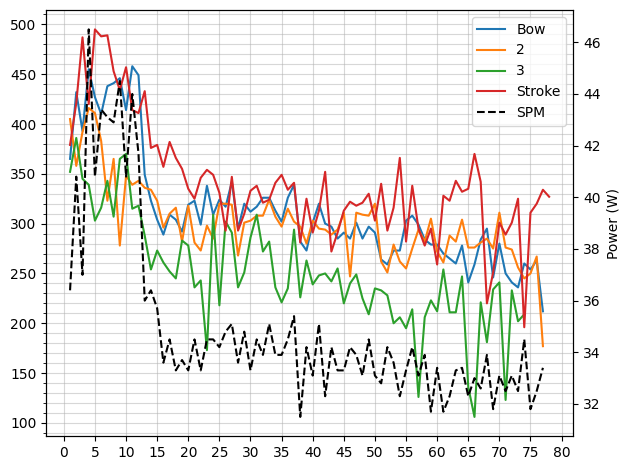

In [3]:
plot_seat('Stroke', '2', '3', 'Bow', 1)

## 3 Seat

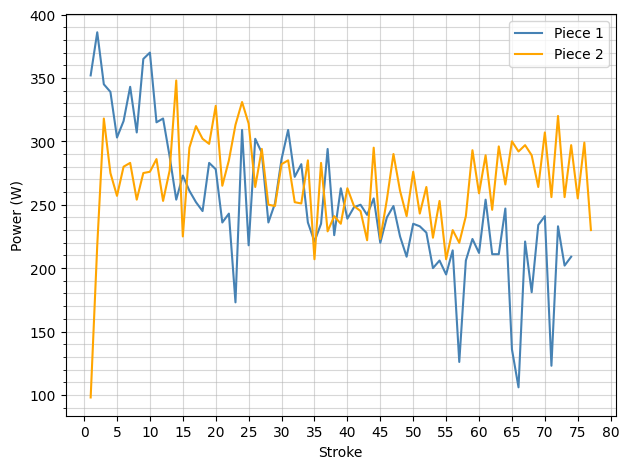

In [4]:
plot_seat('3')

## 2 Seat

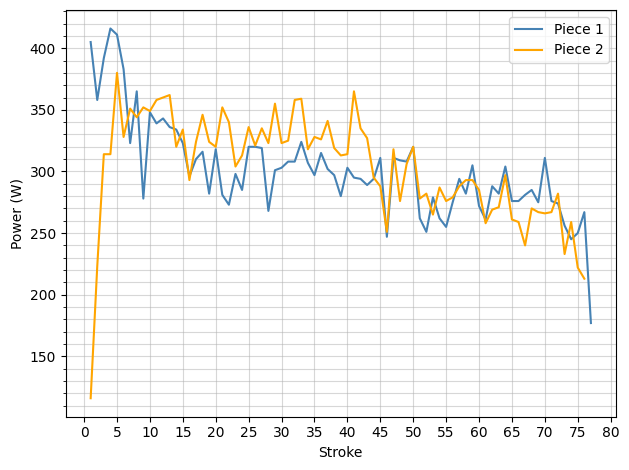

In [5]:
plot_seat('2')

## Bow

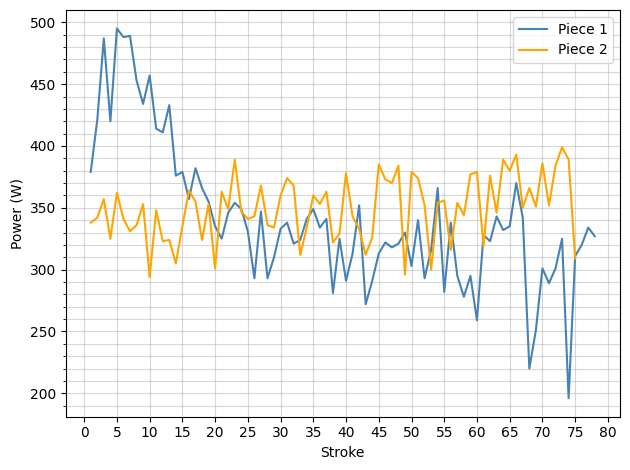

In [6]:
plot_seat('Bow')

# Crew Analysis: 4+ 2x600

This section treats the two files for each seat as the two 600m pieces. Piece 1 includes the start sequence; Piece 2 includes the finish sequence. Roster context used for interpretation:

- Stroke: Kaden, 5'7", 160 lb, 6:47 2k, Senior
- 3 seat: James, 5'9", 160 lb, 6:59 2k, Sophomore
- 2 seat: Jack, 6'7", 200 lb, 6:37 2k, Sophomore
- Bow: telemetry present, rower name not provided


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the notebook work whether it is launched from the repo root or from 424F2x600/.
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "data").exists() and (NOTEBOOK_DIR / "424F2x600" / "data").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "424F2x600"

DATA_DIR = NOTEBOOK_DIR / "data"
SEAT_ORDER = ["Stroke", "3", "2", "Bow"]
PIECE_LABELS = {1: "Piece 1 - Start sequence", 2: "Piece 2 - Finish sequence"}
SEAT_CONTEXT = {
    "Stroke": "Kaden - 5'7, 160 lb, 6:47 2k, Senior",
    "3": "James - 5'9, 160 lb, 6:59 2k, Sophomore",
    "2": "Jack - 6'7, 200 lb, 6:37 2k, Sophomore",
    "Bow": "Bow - rower name not provided",
}

METRICS = [power, spm, dps, length, slip_deg, wash_deg, check_ms, drive_time_s, drive, recovery]


def load_piece(seat, piece):
    df = pd.read_csv(DATA_DIR / f"{seat}P{piece}.csv")
    df["Seat"] = seat
    df["Piece"] = piece
    df["Piece Label"] = PIECE_LABELS[piece]
    df["Seat Context"] = SEAT_CONTEXT[seat]
    return df

crew = pd.concat(
    [load_piece(seat, piece) for piece in [1, 2] for seat in SEAT_ORDER],
    ignore_index=True,
)

crew["Stroke Fraction"] = crew.groupby(["Seat", "Piece"])[stroke].transform(
    lambda s: (s - s.min()) / (s.max() - s.min())
)

summary = (
    crew.groupby(["Piece", "Seat"])[METRICS]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

summary

Power (W)                     SPM                   DPS (m)  \
                  mean    std  min  max   mean   std   min   max    mean   
Piece Seat                                                                 
1     2         301.09  39.41  177  416  34.87  3.20  31.7  44.5    7.83   
      3         250.54  55.73  106  386  34.85  3.23  31.7  44.4    7.86   
      Bow       341.05  58.29  196  495  34.84  3.31  29.2  44.0    7.67   
      Stroke    312.57  57.06  212  458  34.91  3.34  31.5  46.5    7.85   
2     2         303.37  43.81  116  380  36.10  2.57  21.9  39.6    7.43   
      3         267.34  36.61   98  348  36.13  2.51  21.4  38.9    7.41   
      Bow       349.73  25.72  294  399  36.47  1.56  29.8  39.2    7.41   
      Stroke    299.89  25.00  242  360  36.48  1.64  30.3  39.9    7.40   

                    ... Drive Time (s)       Drive %                    \
               std  ...            min   max    mean   std   min   max   
Piece Seat          ...                                                  
1     2       0.61  ...           0.68  1.00   49.65  2.28  43.8  54.7   
      3       0.62  ...           0.65  0.99   49.77  2.35  45.7  56.1   
      Bow     1.07  ...           0.72  1.09   50.29  2.42  44.9  60.8   
      Stroke  0.63  ...           0.60  0.96   48.53  3.16  41.5  54.0   
2     2       0.51  ...           0.75  1.19   50.30  2.14  43.2  56.4   
      3       0.41  ...           0.78  1.37   51.33  2.06  46.3  58.3   
      Bow     0.41  ...           0.76  1.01   50.19  1.96  46.8  54.9   
      Stroke  0.40  ...           0.67  1.04   51.61  2.74  43.7  55.6   

             Recovery %                    
                   mean   std   min   max  
Piece Seat                                 
1     2           50.35  2.28  45.3  56.2  
      3           50.23  2.35  43.9  54.3  
      Bow         49.71  2.42  39.2  55.1  
      Stroke      51.47  3.16  46.0  58.5  
2     2           49.70  2.14  43.6  56.8  
      3           48.67  2.06  41.7  53.7  
      Bow         49.81  1.96  45.1  53.2  
      Stroke      48.39  2.74  44.4  56.3  

[8 rows x 40 columns]

In [8]:
seat_summary = (
    crew.groupby(["Piece", "Seat"])
    .agg(
        strokes=(stroke, "count"),
        avg_rate=(spm, "mean"),
        avg_power=(power, "mean"),
        avg_dps=(dps, "mean"),
        avg_length=(length, "mean"),
        avg_slip=(slip_deg, "mean"),
        avg_wash=(wash_deg, "mean"),
        avg_check=(check_ms, "mean"),
        avg_drive_pct=(drive, "mean"),
        power_cv=(power, lambda s: s.std() / s.mean()),
    )
    .round(2)
    .reset_index()
)

seat_summary["Seat"] = pd.Categorical(seat_summary["Seat"], SEAT_ORDER, ordered=True)
seat_summary = seat_summary.sort_values(["Piece", "Seat"])
seat_summary

,Piece,Seat,strokes,avg_rate,avg_power,avg_dps,avg_length,avg_slip,avg_wash,avg_check,avg_drive_pct,power_cv
3,1,Stroke,77,34.91,312.57,7.85,76.88,13.92,8.59,544.90,48.53,0.18
1,1,3,74,34.85,250.54,7.86,84.02,13.59,20.31,530.89,49.77,0.22
0,1,2,77,34.87,301.09,7.83,82.59,15.87,8.82,536.53,49.65,0.13
2,1,Bow,78,34.84,341.05,7.67,88.31,12.90,6.87,544.31,50.29,0.17
7,2,Stroke,75,36.48,299.89,7.40,74.91,13.07,10.39,529.31,51.61,0.08
5,2,3,77,36.13,267.34,7.41,83.88,12.26,21.06,508.56,51.33,0.14
4,2,2,76,36.10,303.37,7.43,80.12,15.30,8.95,523.30,50.30,0.14
6,2,Bow,75,36.47,349.73,7.41,88.30,12.24,7.48,520.45,50.19,0.07


In [9]:
piece_delta = (
    seat_summary
    .pivot(index="Seat", columns="Piece", values=["avg_rate", "avg_power", "avg_length", "avg_slip", "avg_wash", "avg_check", "avg_drive_pct"])
)

for metric in ["avg_rate", "avg_power", "avg_length", "avg_slip", "avg_wash", "avg_check", "avg_drive_pct"]:
    piece_delta[(metric, "P2 - P1")] = piece_delta[(metric, 2)] - piece_delta[(metric, 1)]

piece_delta.round(2)

avg_rate        avg_power         avg_length        avg_slip         \
Piece         1      2         1       2          1      2        1      2   
Seat                                                                         
Stroke    34.91  36.48    312.57  299.89      76.88  74.91    13.92  13.07   
3         34.85  36.13    250.54  267.34      84.02  83.88    13.59  12.26   
2         34.87  36.10    301.09  303.37      82.59  80.12    15.87  15.30   
Bow       34.84  36.47    341.05  349.73      88.31  88.30    12.90  12.24   

       avg_wash         ... avg_check avg_drive_pct        avg_rate avg_power  \
Piece         1      2  ...         2             1      2  P2 - P1   P2 - P1   
Seat                    ...                                                     
Stroke     8.59  10.39  ...    529.31         48.53  51.61     1.57    -12.68   
3         20.31  21.06  ...    508.56         49.77  51.33     1.28     16.80   
2          8.82   8.95  ...    523.30         49.65  50.30     1.23      2.28   
Bow        6.87   7.48  ...    520.45         50.29  50.19     1.63      8.68   

       avg_length avg_slip avg_wash avg_check avg_drive_pct  
Piece     P2 - P1  P2 - P1  P2 - P1   P2 - P1       P2 - P1  
Seat                                                         
Stroke      -1.97    -0.85     1.80    -15.59          3.08  
3           -0.14    -1.33     0.75    -22.33          1.56  
2           -2.47    -0.57     0.13    -13.23          0.65  
Bow         -0.01    -0.66     0.61    -23.86         -0.10  

[4 rows x 21 columns]

## Piece-Level Read

Piece 2 was cleaner in several boat-moving areas: the crew rated about 1.3-1.6 spm higher, average check dropped for every seat, and the drive percentage moved up. That is consistent with the finish-sequence piece having more connected rhythm and less dead time around the front end.

The main mismatch is power distribution. Bow produced the highest measured power and length in both pieces, while 2 seat did not separate from Stroke despite Jack having the fastest 2k and the largest frame. 3 seat improved power in Piece 2 but carried the largest wash by a wide margin, which points to finish efficiency rather than raw effort.


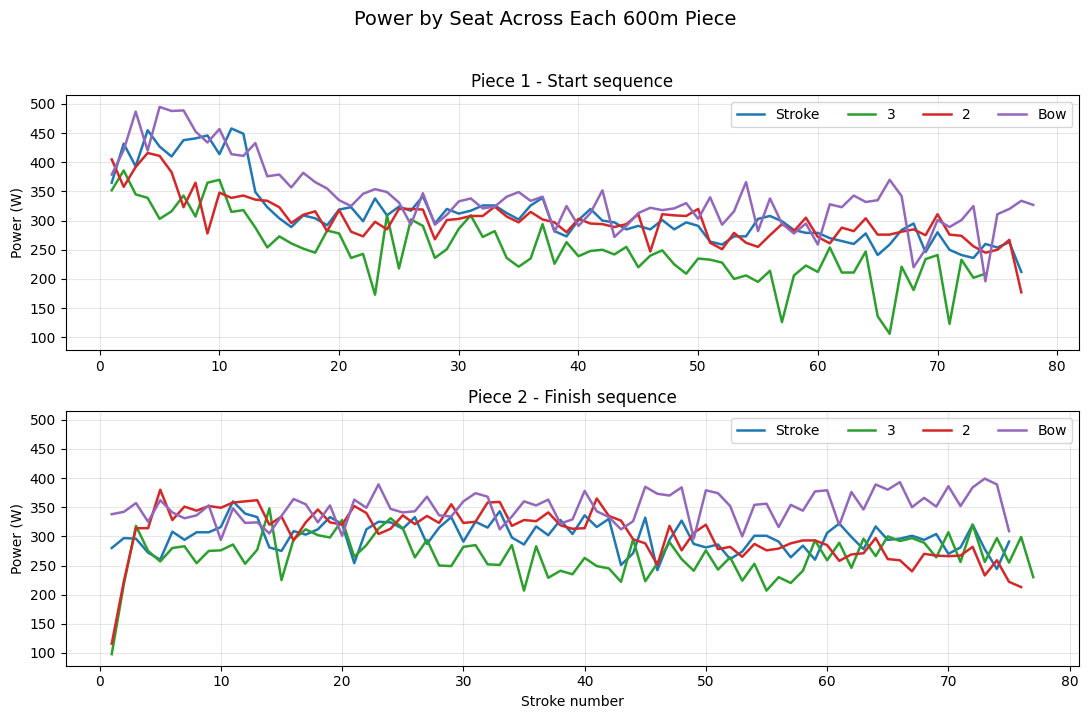

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False, sharey=True)
colors = {"Stroke": "#1f77b4", "3": "#2ca02c", "2": "#d62728", "Bow": "#9467bd"}

for ax, piece in zip(axes, [1, 2]):
    for seat in SEAT_ORDER:
        df = crew[(crew["Piece"] == piece) & (crew["Seat"] == seat)]
        ax.plot(df[stroke], df[power], label=seat, linewidth=1.8, color=colors[seat])
    ax.set_title(PIECE_LABELS[piece])
    ax.set_ylabel("Power (W)")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4, loc="upper right")

axes[-1].set_xlabel("Stroke number")
fig.suptitle("Power by Seat Across Each 600m Piece", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

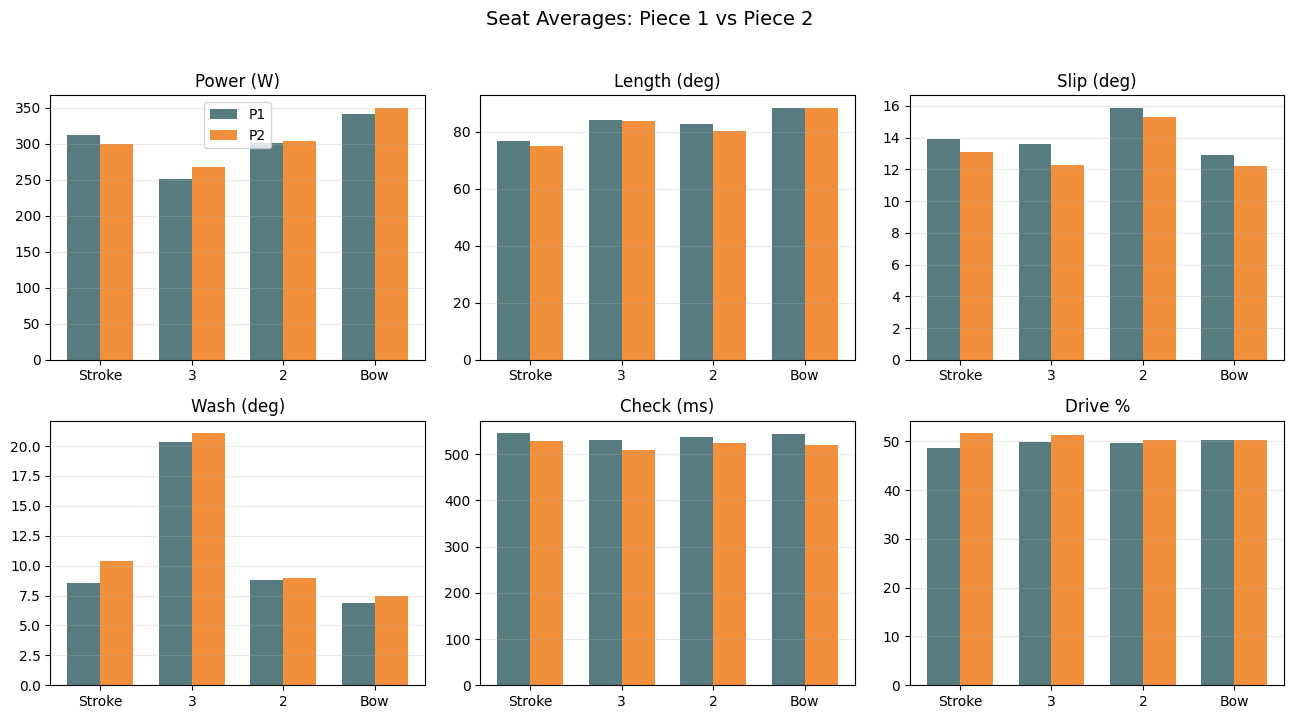

In [11]:
metrics_to_plot = [avg for avg in ["avg_power", "avg_length", "avg_slip", "avg_wash", "avg_check", "avg_drive_pct"]]
labels = {
    "avg_power": "Power (W)",
    "avg_length": "Length (deg)",
    "avg_slip": "Slip (deg)",
    "avg_wash": "Wash (deg)",
    "avg_check": "Check (ms)",
    "avg_drive_pct": "Drive %",
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()
bar_width = 0.36
x = np.arange(len(SEAT_ORDER))

for ax, metric in zip(axes, metrics_to_plot):
    p1 = seat_summary[seat_summary["Piece"] == 1].set_index("Seat").loc[SEAT_ORDER, metric]
    p2 = seat_summary[seat_summary["Piece"] == 2].set_index("Seat").loc[SEAT_ORDER, metric]
    ax.bar(x - bar_width / 2, p1, width=bar_width, label="P1", color="#587b7f")
    ax.bar(x + bar_width / 2, p2, width=bar_width, label="P2", color="#f28f3b")
    ax.set_title(labels[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(SEAT_ORDER)
    ax.grid(True, axis="y", alpha=0.25)

axes[0].legend()
fig.suptitle("Seat Averages: Piece 1 vs Piece 2", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

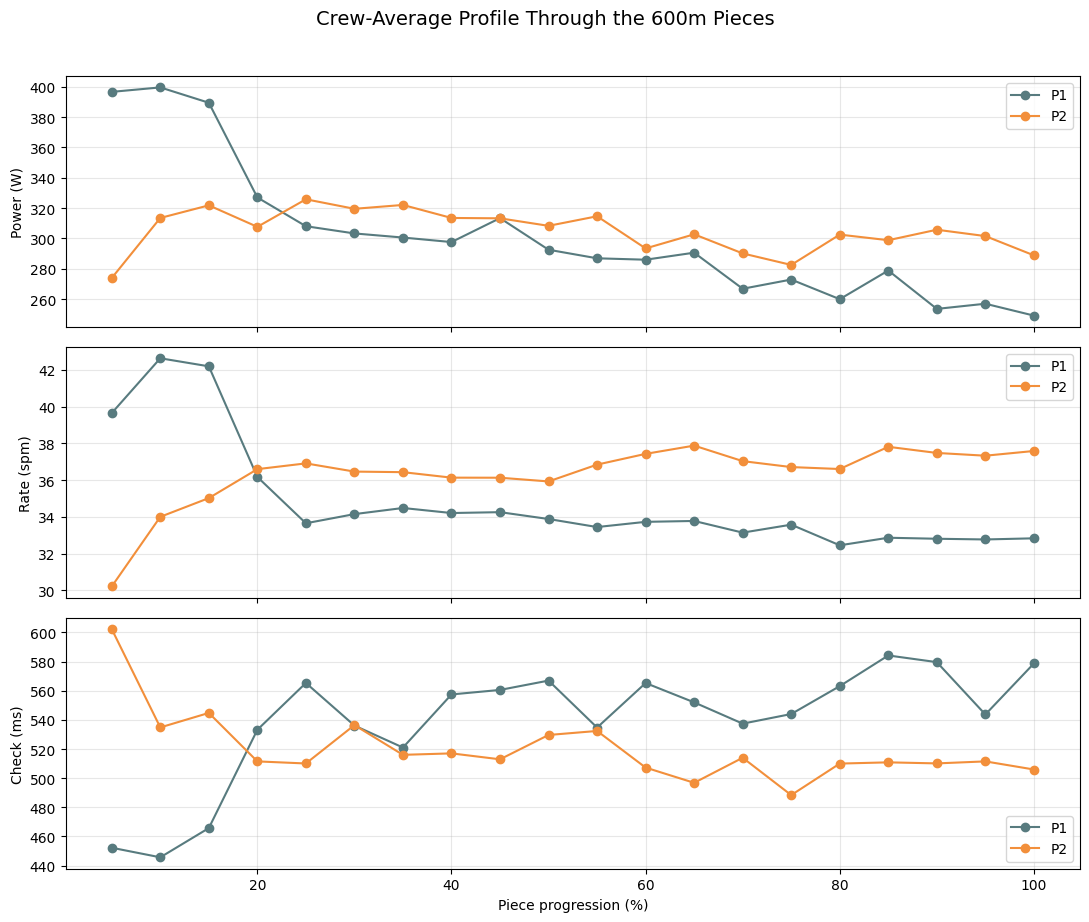

In [12]:
# Normalize each seat to the same 0-100% piece progression before averaging across monitors.
trace_metrics = [power, spm, speed, dps, check_ms]
progress_bins = np.linspace(0, 1, 21)
crew["Progress Bin"] = pd.cut(crew["Stroke Fraction"], bins=progress_bins, labels=progress_bins[1:], include_lowest=True)

crew_trace = (
    crew.groupby(["Piece", "Progress Bin"], observed=True)[trace_metrics]
    .mean()
    .reset_index()
)
crew_trace["Progress"] = crew_trace["Progress Bin"].astype(float) * 100

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
trace_plot_metrics = [(power, "Power (W)"), (spm, "Rate (spm)"), (check_ms, "Check (ms)")]

for ax, (metric, label) in zip(axes, trace_plot_metrics):
    for piece, color in [(1, "#587b7f"), (2, "#f28f3b")]:
        df = crew_trace[crew_trace["Piece"] == piece]
        ax.plot(df["Progress"], df[metric], marker="o", label=f"P{piece}", color=color)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Piece progression (%)")
fig.suptitle("Crew-Average Profile Through the 600m Pieces", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
phase_edges = [0, 0.20, 0.80, 1.0]
phase_labels = ["Start / first 20%", "Body / middle 60%", "Finish / last 20%"]
crew["Phase"] = pd.cut(crew["Stroke Fraction"], bins=phase_edges, labels=phase_labels, include_lowest=True)

phase_summary = (
    crew.groupby(["Piece", "Phase"], observed=True)
    .agg(
        avg_rate=(spm, "mean"),
        avg_power=(power, "mean"),
        avg_dps=(dps, "mean"),
        avg_check=(check_ms, "mean"),
        avg_drive_pct=(drive, "mean"),
    )
    .round(2)
)

phase_summary

avg_rate  avg_power  avg_dps  avg_check  \
Piece Phase                                                        
1     Start / first 20%     40.13     377.94     6.97     474.35   
      Body / middle 60%     33.74     290.11     8.04     550.72   
      Finish / last 20%     32.82     259.76     7.96     571.41   
2     Start / first 20%     33.88     304.11     7.57     549.52   
      Body / middle 60%     36.71     307.13     7.39     513.94   
      Finish / last 20%     37.54     298.75     7.31     509.54   

                         avg_drive_pct  
Piece Phase                             
1     Start / first 20%          50.19  
      Body / middle 60%          49.35  
      Finish / last 20%          49.53  
2     Start / first 20%          50.10  
      Body / middle 60%          51.01  
      Finish / last 20%          51.17

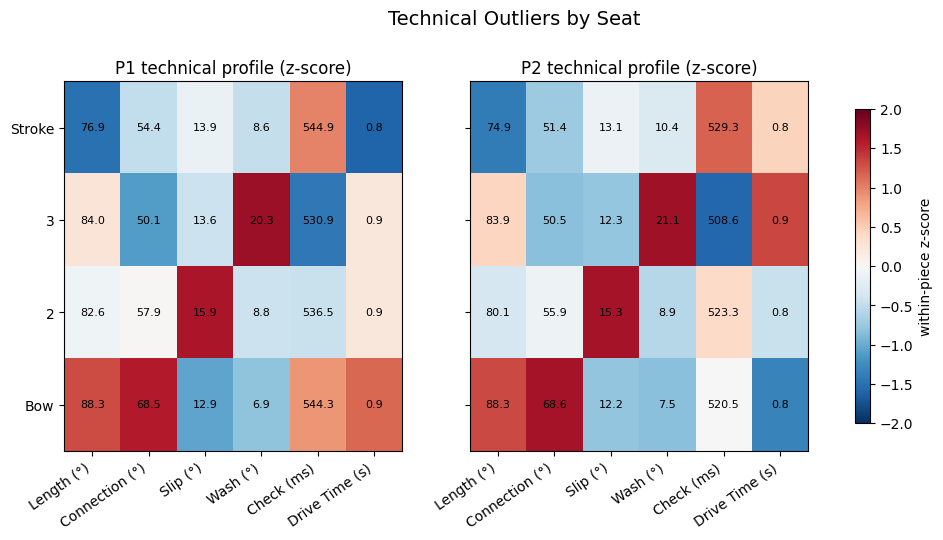

In [14]:
technical_metrics = [length, connection, slip_deg, wash_deg, check_ms, drive_time_s]
tech = crew.groupby(["Piece", "Seat"])[technical_metrics].mean().round(2).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, piece in zip(axes, [1, 2]):
    heat = tech[tech["Piece"] == piece].set_index("Seat").loc[SEAT_ORDER, technical_metrics]
    standardized = (heat - heat.mean()) / heat.std(ddof=0)
    im = ax.imshow(standardized, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
    ax.set_title(f"P{piece} technical profile (z-score)")
    ax.set_xticks(np.arange(len(technical_metrics)))
    ax.set_xticklabels(technical_metrics, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(SEAT_ORDER)))
    ax.set_yticklabels(SEAT_ORDER)
    for i in range(len(SEAT_ORDER)):
        for j, metric in enumerate(technical_metrics):
            ax.text(j, i, f"{heat.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.85, label="within-piece z-score")
fig.suptitle("Technical Outliers by Seat", y=1.03, fontsize=14)
plt.show()

## Technical Review and Coaching Priorities

### Boat-Wide Priorities

1. **Connect the front end without adding slip.** The crew has enough raw horsepower for this lineup, but the catch is not equally effective across the boat. 2 seat averaged the most slip in both pieces, which means Jack is likely missing some early water despite being the biggest and fastest erg in the boat. The goal is not a harder catch; it is a quicker placement, earlier suspension, and pressure that builds immediately after the blade is buried.

2. **Clean up the finish, especially through 3 seat.** James' wash is the standout technical issue: roughly 20-21 degrees in both pieces, more than double most of the boat. That usually shows up as pressure leaking away near the release, blades washing out, or body/handle timing that opens the finish too early. In a 4+, that can make the stern pair feel like they are working while the shell loses run at the back end.

3. **Use Piece 2 rhythm as the model.** Piece 2 had higher rate, lower check, and a higher drive percentage. That suggests the finish sequence gave the boat more continuous motion. The crew should try to carry that same ratio into the start: accelerate the rate without shortening into ineffective strokes, and keep the recovery moving with the stern pair setting a clean rhythm.

4. **Align power with role and body size.** Bow measured the strongest power and longest stroke in both pieces, while 2 seat's output was only slightly above Stroke and below Bow. With Jack's size and erg score, the middle of the boat should be a major engine room. The immediate target is converting his length into connected pressure rather than just more arc.

### Seat-Specific Notes

**Stroke - Kaden:** Kaden sets a consistent rate and keeps slip controlled relative to the boat. His length is the shortest in the lineup, which is expected given height, but the stern pair needs him long enough at the front that the taller athletes behind him do not row through the rhythm. Main focus: maintain the Piece 2 drive ratio while keeping the first ten strokes long and connected, not just high.

**3 seat - James:** James improved power in Piece 2, which is a good sign, but the wash number is the most urgent technical limiter. He should prioritize finishing with pressure through the pin, tapping down cleanly, and avoiding a handle path that pulls the blade down or out before the release. Main focus: blade stays loaded until extraction, then hands move away together with Stroke.

**2 seat - Jack:** Jack has the physical profile to be the biggest contributor, but the telemetry points to too much front-end slip and less measured power than expected. His length is good, but it is not producing a matching power advantage. Main focus: get the blade locked before opening the body, then suspend from the lats/legs through the first half of the drive.

**Bow:** Bow is providing a lot of measured length and power, with comparatively low slip and wash. That is useful, but bow should make sure the extra length does not pull the boat around or force timing behind the stern pair. Main focus: keep the long arc quiet and matched to the stroke rhythm.

### Practice Emphasis

- **Pick drill into first 10 strokes:** 3-5 strokes at arms/body only, then half slide, then full slide, immediately into a start. Watch whether James can keep wash down as pressure rises.
- **Top-quarter placement drill:** Pause at bodies over, roll to the catch, place, and drive the first six inches together. This is for Jack's slip and the crew's catch timing.
- **Feet-out steady state at rate 22-24:** Good for exposing finish instability and excess layback. James should feel pressure stay on until the tap-down, not disappear before it.
- **Start-to-base transitions:** Since Piece 1 included the start sequence, rehearse the shift from high strokes to base rhythm with the same lower-check feel seen in Piece 2.
- **Finish sequence with rate cap:** Build to the final 20 strokes without letting the finish wash increase. If pressure rises but wash rises too, the crew is spending energy without keeping the blade loaded.

### Bottom Line

The crew's best next gain is not more effort; it is making the effort land in the water at the same time. Piece 2 shows that the group can rate higher with less check. If Jack connects earlier and James holds cleaner pressure through the release, the boat should get more run from the same fitness and make the start/finish sequences feel less frantic.
